In [1]:
MODEL_ID = "google/gemma-4-E2B-it" # @param ["google/gemma-4-E2B-it","google/gemma-4-E4B-it", "google/gemma-4-31B-it", "google/gemma-4-26B-A4B-it"]

from transformers import AutoProcessor, AutoModelForMultimodalLM

model = AutoModelForMultimodalLM.from_pretrained(MODEL_ID, dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained(MODEL_ID)

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [ ]:
from transformers import TextStreamer

message = [
    {
        "role": "user", "content": "What is the water formula?"
    }
]

text = processor.apply_chat_template(message,
                                    tokenize=False,
                                    add_generation_prompt=True,
                                    enable_thinking=True)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]

streamer = TextStreamer(processor)
outputs = model.generate(**inputs, streamer=streamer, max_new_tokens=1024)

<bos><|turn>system
<|think|><turn|>
<|turn>user
What is the water formula?<turn|>
<|turn>model
<|channel>thought
Thinking Process:

1.  **Analyze the Request:** The user is asking "What is the water formula?"
2.  **Interpret Ambiguity:** This phrase is highly ambiguous. It could refer to:
    *   **Chemical Formula:** The molecular formula for water ($\text{H}_2\text{O}$).
    *   **Chemical Equation:** The reaction involved in water formation (e.g., $\text{2H}_2 + \text{O}_2 \rightarrow \text{2H}_2\text{O}$).
    *   **Physical/Structural Formula:** The molecular structure (VSEPR theory, bond angles, etc.).
    *   **Conceptual Formula:** The role of water in biology or chemistry (e.g., polarity, hydrogen bonding).
3.  **Determine the Most Likely Intent:** In a general context, when someone asks for a "formula" related to water, they almost always mean the *chemical formula*.
4.  **Formulate the Primary Answer (Chemical Formula):**
    *   The chemical formula for water is $\text{H}_2

In [3]:
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
result = processor.parse_response(response)

for key, value in result.items():
  if key == "role":
    print(f"Role: {value}")
  elif key == "thinking":
    print(f"\n=== Thoughts ===\n{value}")
  elif key == "content":
    print(f"\n=== Answer ===\n{value}")
  elif key == "tool_calls":
    print(f"\n=== Tool Calls ===\n{value}")
  else:
    print(f"\n{key}: {value}...\n")

Role: assistant

=== Thoughts ===
Thinking Process:

1.  **Analyze the Request:** The user is asking "What is the water formula?"
2.  **Interpret Ambiguity:** This phrase is highly ambiguous. It could refer to:
    *   **Chemical Formula:** The molecular formula for water ($\text{H}_2\text{O}$).
    *   **Chemical Equation:** The reaction involved in water formation (e.g., $\text{2H}_2 + \text{O}_2 \rightarrow \text{2H}_2\text{O}$).
    *   **Physical/Structural Formula:** The molecular structure (VSEPR theory, bond angles, etc.).
    *   **Conceptual Formula:** The role of water in biology or chemistry (e.g., polarity, hydrogen bonding).
3.  **Determine the Most Likely Intent:** In a general context, when someone asks for a "formula" related to water, they almost always mean the *chemical formula*.
4.  **Formulate the Primary Answer (Chemical Formula):**
    *   The chemical formula for water is $\text{H}_2\text{O}$.
    *   Explain what the components mean (2 Hydrogen atoms, 1 Oxygen

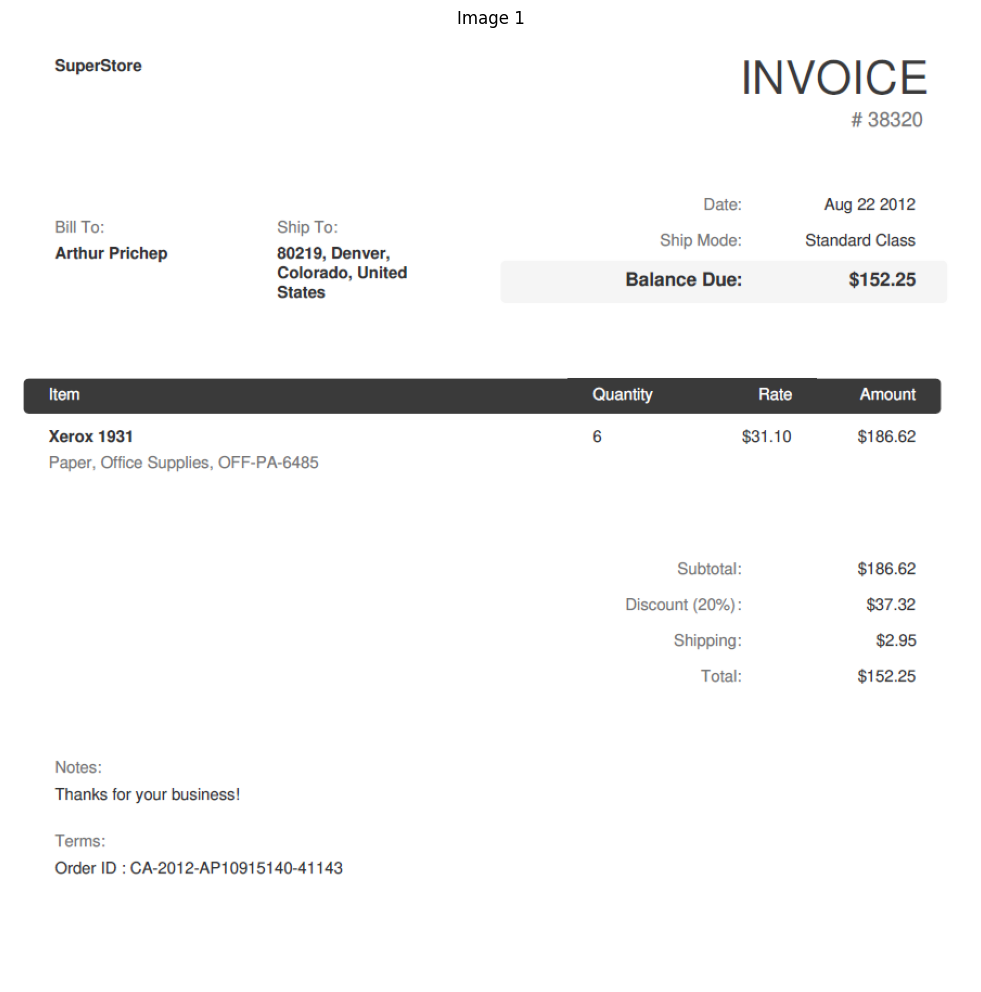

<bos><|turn>system
<|think|><turn|>
<|turn>user


<|image><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|imag

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

prompt = "generate the content of this image in JSON ftructure format"

# download image
image = Image.open("invoices/sample_invoice.png")

# Display all images
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(image)
ax.set_title("Image 1")
ax.axis("off")
plt.tight_layout()
plt.show()

message = [
    {
        "role": "user", "content": [
          {"type": "image"},
          {"type": "text", "text": prompt}
        ]
    }
]

text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True, enable_thinking=True)
inputs = processor(text=text, images=image, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]

streamer = TextStreamer(processor)
outputs = model.generate(**inputs, streamer=streamer, max_new_tokens=2064)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

result = processor.parse_response(response)

In [17]:
for key, value in result.items():
  if key == "role":
    print(f"Role: {value}")
  elif key == "thinking":
    print(f"\n=== Thoughts ===\n{value}")
  elif key == "content":
    print(f"\n=== Answer ===\n{value}")
  elif key == "tool_calls":
    print(f"\n=== Tool Calls ===\n{value}")
  else:
    print(f"\n{key}: {value}...\n")

Role: assistant

=== Thoughts ===
Here's a thinking process to generate the desired JSON output:

1.  **Analyze the Request:** The user wants the content of the provided image (an invoice) in JSON format.

2.  **Examine the Image Content (Information Extraction):** I need to systematically read and categorize the data presented in the invoice.

    *   **Header/Title:** INVOICE, # 38320, SuperStore.
    *   **Bill To:** Arthur Prichep.
    *   **Ship To:** 80219, Denver, Colorado, United States.
    *   **Date:** Aug 22 2012.
    *   **Ship Mode:** Standard Class.
    *   **Financial Summary:**
        *   Balance Due: $152.25.
    *   **Line Items (The main body):**
        *   Item: Xerox 1931
        *   Description: Paper, Office Supplies, OFF-PA-6485
        *   Quantity: 6
        *   Rate: $31.10
        *   Amount: $186.62
    *   **Calculations/Summary Breakdown:**
        *   Subtotal: $186.62
        *   Discount (20%): $37.32
        *   Shipping: $2.95
        *   Total: $

In [14]:
result

{'role': 'assistant',
 'thinking': 'Here\'s a thinking process to arrive at the desired JSON output:\n\n1.  **Analyze the Request:** The goal is to convert the content of the provided image (an invoice) into a JSON structure format.\n\n2.  **Deconstruct the Image (Information Extraction):** I need to systematically read and categorize all the data points visible on the invoice.\n\n    *   **Header/Branding:** "SuperStore", "INVOICE", "# 38320".\n    *   **Billing/Recipient Information (Bill To):** "Arthur Pricep" (Wait, let me re-read the image carefully. It says "Arthur Pricep").\n    *   **Shipping Information (Ship To):** "80219, Denver, Colorado, United States".\n    *   **Dates/Metadata:**\n        *   Date: "Aug 22 2012"\n        *   Ship Mode: "Standard Class"\n    *   **Line Items (Item Table):**\n        *   Item: "Xerox 1931"\n        *   Description: "Paper, Office Supplies, OFF-PA-6485"\n        *   Quantity: 6\n        *   Rate: $31.10\n        *   Amount: $186.62\n    *  

In [20]:
from transformers import TextStreamer

weather_function_schema = {
    "type": "function",
    "function": {
        "name": "get_current_temperature",
        "description": "Gets the current temperature for a given location.",
        "parameters": {
            "type": "object",
            "properties": {
                "location": {
                    "type": "string",
                    "description": "The city name, e.g. San Francisco",
                },
            },
            "required": ["location"],
        },
    }
}

message = [
    {
        "role": "system", "content": "You are a helpful assistant."
    },
    {
        "role": "user", "content": "What's the temperature in London?"
    }
]

text = processor.apply_chat_template(message, tools=[weather_function_schema], tokenize=False, add_generation_prompt=True)
inputs = processor(text=text, return_tensors="pt").to(model.device)
streamer = TextStreamer(processor)
outputs = model.generate(**inputs, streamer=streamer, max_new_tokens=64)

<bos><|turn>system
You are a helpful assistant.<|tool>declaration:get_current_temperature{description:<|"|>Gets the current temperature for a given location.<|"|>,parameters:{properties:{location:{description:<|"|>The city name, e.g. San Francisco<|"|>,type:<|"|>STRING<|"|>}},required:[<|"|>location<|"|>],type:<|"|>OBJECT<|"|>}}<tool|><turn|>
<|turn>user
What's the temperature in London?<turn|>
<|turn>model
<|tool_call>call:get_current_temperature{location:<|"|>London<|"|>}<tool_call|><|tool_response>


## Function calling

In [35]:
from transformers import TextStreamer
import re
import json


def get_current_temperature(location: str):
    """
    Gets the current temperature for a given location.

    Args:
        location: The city name, e.g. San Francisco
    """
    return "15°C"

message = [
    {
        "role": "user", "content": "What's the temperature in London?"
    }
]

weather_function_schema = {
    "type": "function",
    "function": {
        "name": "get_current_temperature",
        "description": "Gets the current temperature for a given location.",
        "parameters": {
            "type": "object",
            "properties": {
                "location": {
                    "type": "string",
                    "description": "The city name, e.g. San Francisco",
                },
            },
            "required": ["location"],
        },
    }
}


def extract_tool_calls(text):
    def cast(v):
        try: return int(v)
        except:
            try: return float(v)
            except: return {'true': True, 'false': False}.get(v.lower(), v.strip("'\""))

    return [{
        "name": name,
        "arguments": {
            k: cast((v1 or v2).strip())
            for k, v1, v2 in re.findall(r'(\w+):(?:<\|"\|>(.*?)<\|"\|>|([^,}]*))', args)
        }
    } for name, args in re.findall(r"<\|tool_call>call:(\w+)\{(.*?)\}<tool_call\|>", text, re.DOTALL)]


message = [
    {
        "role": "system", "content": "You are a helpful assistant."
    },
    {
        "role": "user", "content": "What's the temperature in London?"
    }
]
#out = model.generate(**inputs, max_new_tokens=128)
text = processor.apply_chat_template(message, tools=[weather_function_schema], tokenize=False, add_generation_prompt=True)
inputs = processor(text=text, return_tensors="pt").to(model.device)
streamer = TextStreamer(processor)
outputs = model.generate(**inputs, streamer=streamer, max_new_tokens=64)
generated_tokens = outputs[0][len(inputs["input_ids"][0]):]
output = processor.decode(generated_tokens, skip_special_tokens=False)

<bos><|turn>system
You are a helpful assistant.<|tool>declaration:get_current_temperature{description:<|"|>Gets the current temperature for a given location.<|"|>,parameters:{properties:{location:{description:<|"|>The city name, e.g. San Francisco<|"|>,type:<|"|>STRING<|"|>}},required:[<|"|>location<|"|>],type:<|"|>OBJECT<|"|>}}<tool|><turn|>
<|turn>user
What's the temperature in London?<turn|>
<|turn>model
<|tool_call>call:get_current_temperature{location:<|"|>London<|"|>}<tool_call|><|tool_response>


In [36]:
calls = extract_tool_calls(output)
if calls:
    # Call the function and get the result
    #####################################
    # WARNING: This is a demonstration. #
    #####################################
    # Using globals() to call functions dynamically can be dangerous in
    # production. In a real application, you should implement a secure way to
    # map function names to actual function calls, such as a predefined
    # dictionary of allowed tools and their implementations.
    results = [
        {"name": c['name'], "response": globals()[c['name']](**c['arguments'])}
        for c in calls
    ]

    message.append({
        "role": "assistant",
        "tool_calls": [
            {"function": call} for call in calls
        ],
        "tool_responses": results
    })
    print(json.dumps(message[-1], indent=2))

{
  "role": "assistant",
  "tool_calls": [
    {
      "function": {
        "name": "get_current_temperature",
        "arguments": {
          "location": "London"
        }
      }
    }
  ],
  "tool_responses": [
    {
      "name": "get_current_temperature",
      "response": "15\u00b0C"
    }
  ]
}


In [23]:
import re
import json

def extract_tool_calls(text):
    def cast(v):
        try: return int(v)
        except:
            try: return float(v)
            except: return {'true': True, 'false': False}.get(v.lower(), v.strip("'\""))

    return [{
        "name": name,
        "arguments": {
            k: cast((v1 or v2).strip())
            for k, v1, v2 in re.findall(r'(\w+):(?:<\|"\|>(.*?)<\|"\|>|([^,}]*))', args)
        }
    } for name, args in re.findall(r"<\|tool_call>call:(\w+)\{(.*?)\}<tool_call\|>", text, re.DOTALL)]

calls = extract_tool_calls(output)
if calls:
    # Call the function and get the result
    #####################################
    # WARNING: This is a demonstration. #
    #####################################
    # Using globals() to call functions dynamically can be dangerous in
    # production. In a real application, you should implement a secure way to
    # map function names to actual function calls, such as a predefined
    # dictionary of allowed tools and their implementations.
    results = [
        {"name": c['name'], "response": globals()[c['name']](**c['arguments'])}
        for c in calls
    ]

    message.append({
        "role": "assistant",
        "tool_calls": [
            {"function": call} for call in calls
        ],
        "tool_responses": results
    })
    print(json.dumps(message[-1], indent=2))

{
  "role": "assistant",
  "tool_calls": [
    {
      "function": {
        "name": "get_current_weather",
        "arguments": {
          "location": "Tokyo, JP"
        }
      }
    }
  ],
  "tool_responses": [
    {
      "name": "get_current_weather",
      "response": {
        "temperature": 15,
        "weather": "sunny"
      }
    }
  ]
}


In [24]:
text = processor.apply_chat_template(message, tools=tools, tokenize=False, add_generation_prompt=True)
inputs = processor(text=text, return_tensors="pt").to(model.device)
out = model.generate(**inputs, max_new_tokens=128)
generated_tokens = out[0][len(inputs["input_ids"][0]):]
output = processor.decode(generated_tokens, skip_special_tokens=True)
print(f"Output: {output}")
message[-1]["content"] = output

Output: I'm sorry, I can only get the weather for locations I have specific data for, and I do not have the current weather for London.
